# Navigation and Position QC

<div class="alert alert-block alert-warning">
This notebook expects the geowhizz HDF5 files to be already prepared. You should run the `Prepare_XYZ` notebook first.
<div>

___

Import the required modules, and set the path to the geowhizz files.

In [1]:
from pathlib import Path

import AirGravQC as qc

In [3]:
EastVicHDF_file = Path(r'./EastVicData/EastVic.hdf5')
EastVicTestHDF_file = Path(r'./EastVicData/EastVicTest.hdf5')
EastVicRepHDF_file = Path(r'./EastVicData/EastVicRepeats.hdf5')
EastVicHDF_plan = Path(r'./EastVicData/EastVicPlan.hdf5')

canobieHDF_file = Path(r'./CanobieData/Canobie.hdf5')
canobieHDF_plan = Path(r'./CanobieData/CanobiePlan.hdf5')

In [ ]:
if not (canobieHDF_file.exists() and canobieHDF_plan.exists()):
    %run ./Prepare_CanobieData.ipynb

In [ ]:
if not (EastVicHDF_file.exists() and EastVicTestHDF_file.exists() and EastVicRepHDF_file.exists() and EastVicHDF_plan.exists()):
    %run ./Prepare_CanobieData.ipynb

___

**GNSS**

Accurate knowledge of the sensor position is important. In gravimetry, it is critical for calculating the kinematic accelerations that must be removed from the gravimeter measurements. In gradiometry the accuracy requirement is not quite as demanding but it is still important since it limits the accuracy of the terrain corrections.

The accuracy of GNSS (Global Navigation Satellite System) positions is usually better when the number of visible satellites, `NSATS`, is large and the position, vertical and horizontal dilutions of position (PDOP, `VDOP` and `HDOP` respectively) are small. Contracts will often stipulate the minimum number of satellites, and maximum values for PDOP, VDOP and HDOP. The requirements tend to be a little more demanding for gravimetry than for gradiometry.

Typical values might be:

    airborne gravimetry - a minimum of 6 GNSS satellites visible, and PDOP, HDOP and VDOP to not exceed 4;
    airborne gradi0metry - a minimum of 5 GNSS satellites visible, and PDOP, HDOP and VDOP to not exceed 4.   

In [4]:
qc.checkGNSS(EastVicHDF_file, 'NSATS', 'PDOP', 'VDOP', 'HDOP', nsats_min=5, max_pdop=4, 
                  max_hdop=4, max_vdop=4)

In EastVic, checked num sats, PDOP, VDOP and HDOP. Found 0 errors.



___

**Horizontal Position**

Typically surveys are planned so that the aircraft traverses a series of parallel lines, collecting data along each. The line spacing is an important determinant of the spatial resolution of the survey. Furthermore, the data are usually gridded at a cell spacing approximately one-fifth of the planned line spacing.

If the actual flight path deviates significantly from the planned path, then there will be areas of the survey where the spatial resolution of the data may be poorer than desired, and there will be areas where the gridding must interpolate over more grid cells between measurements than planned. Interpolation errors will be accordingly greater in those areas as a consequence.

The check in this example requires that all flown lines are within $40\,m$ of the planned line, with any exceedances persisting for less than $1000\,m$. The check is repeated for just line `2345.510` to demonstrate the plotting that occurs should a line fail the check.

In [5]:
qc.checkXYPlan(EastVicHDF_plan, EastVicHDF_file, allowance=40.0, maxCounter=0,
               maxDistance=1000.0, plot_flag=False)


0 exceedances previously known in the database.

All lines in plan and checked.

1 horizontal exceedances.

1 lines with horizontal exceedances.

L 2345.51:1018 deviates more than 40.0 m for 85 fids (2380 m), max exceedance = 265 m.
  From (463608 E 5766708 N) to (461732 E 5765243 N).



0 exceedances previously known in the database.

All lines in plan and checked.

1 horizontal exceedances.

1 lines with horizontal exceedances.

L 2345.51:1018 deviates more than 40.0 m for 85 fids (2380 m), max exceedance = 265 m.
  From (463608 E 5766708 N) to (461732 E 5765243 N).


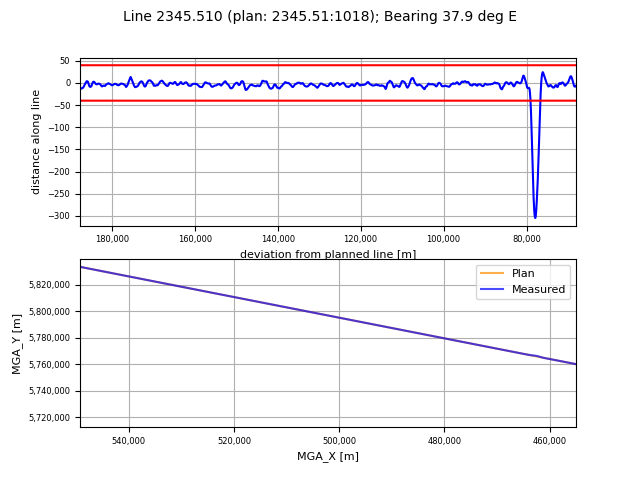

In [6]:
qc.checkXYPlan(EastVicHDF_plan, EastVicHDF_file, allowance=40.0, maxCounter=0,
               maxDistance=1000.0, lines=['2345.510'], plot_flag=True)

___

**Vertical Position**

The vertical positions of the measurements are also constrained. The spatial resolution of the data is affected by the ground clearance, the sample spacing, and the filtering applied to the data. It is desirable to fly sufficiently low that the spatial resolution is not limited by survey height. The climb rate of the aircraft, as well as the presence of any obstacles limits this in practice.

Specifications might require the position to be close to a given height above the ground, or some constant altitude relative to a datum (geoid or ellipsoidal altitude) but often the requirement is that the aircraft remain within a given distance of a preplanned survey height, often called the drape.

Here we check that the aircraft remains within $20\,m$ of the planned height, with no exceedances persisting for more than $1000\,m$.


All lines in plan and checked.

Total number of exceedances = 3 over 3 erroneous lines.

0 exceedances known in the database.


L 2343.51:1018 deviates more than 20.0 m for 154 fids (4484 m), max exceedance = 152.3 m.
  From (461807 E, 5763982 N) to (465341 E, 5766742 N).
L 2345.5:1018 deviates more than 20.0 m for 179 fids (5170 m), max exceedance = 219.0 m.
  From (464003 E, 5766952 N) to (459909 E, 5763794 N).
L 2345.51:1018 deviates more than 20.0 m for 201 fids (5849 m), max exceedance = 158.2 m.
  From (465460 E, 5768099 N) to (460853 E, 5764497 N).


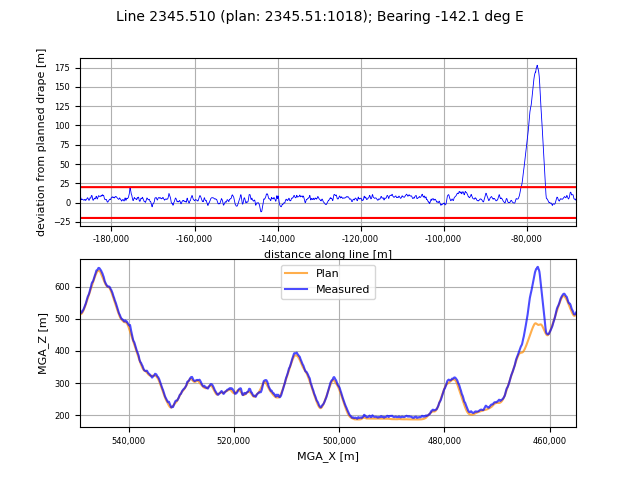

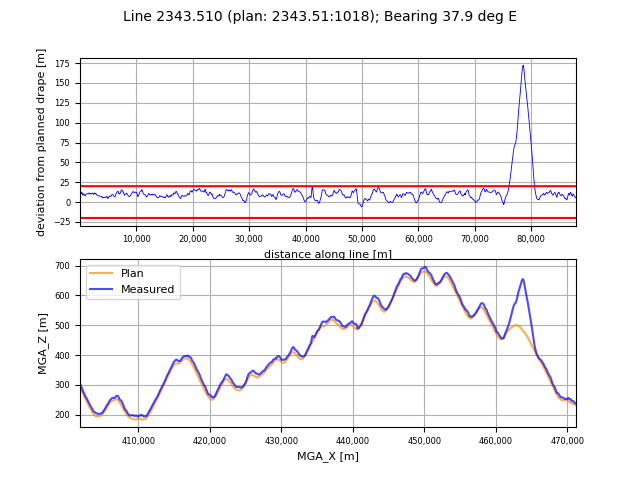

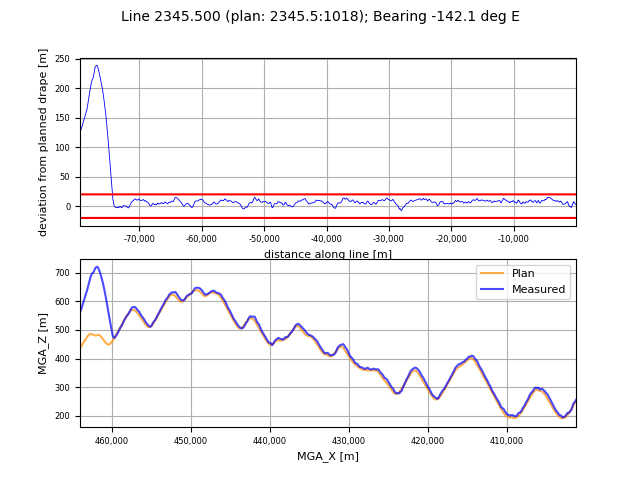

In [7]:
qc.checkVertPlan(EastVicHDF_plan, EastVicHDF_file, allowance=20.0, maxCounter=0,
                 maxDistance=1000.0, plot_flag=True)

___

**Segment Lengths**

For operational reasons, a single planned survey line might be flown as a series of line segments, or as one segment. The length of all individually flown segments must exceed some minimum length. There are several reasons for setting a minimum. Where data are to be tie-line levelled, the segment must cross several control lines and so must be longer than two or three control line separations. For analysis of the spectral content or the statistics of the data, the segment length should be much longer than the spatial resolution of the data. And, for gradiometer surveys, the segment length should be large enough to allow for the noise reduction using regression against dynamic variables.

Typically the minimum length might around $10\,km$ for gradiometry and around $40\,km$ for gravimetry. This gravimetry analysis sets the minimum at $38\,km$.

In [8]:
qc.checkLineLengths(EastVicHDF_file, min_len=38.0)

Number failed lines = 0


___

**Line Overlaps**

When a survey line is flown as more than one segment, the segments must overlap by some minimum amount in order to avoid any end-of-line effects (inlcuding those due to filtering).

In [10]:
qc.checkOverlaps(EastVicHDF_file, min_overlap=10., plot_flag=False)

3 coincident lines found.
All overlaps meet requirement (>10.0 km).


___

**Heading**

Occasionally contracts will set a specification on aircraft heading. Some care is required here because there is some risk of confusion about definitions. The track is the angle made between North and the line of motion of the aircraft (imagined as a track projected onto flat ground). The angle between North and the line defined by the nose-to-tail of the aircraft is the heading. Any cross wind will mean that the heading is different to the track. Nevertheless sometimes heading is reported as track, or vice versa.

Another potential cause of confusion is the distinction between magnetic North and true North. Here we mean true North.

And sometimes heading is called bearing.

The checkHeading function checks the given `heading` channel against the given allowed angles (in degrees) and reports any differences greater than some allowed difference. If the `heading` channel contains track data, then that is what is checked. If the name of the `heading` channel is not supplied, then `checkHeading` calculates the **track** angle from the position data and checks against that.

**Be warned**

  Checked 8 lines for heading - nominal > tolerance 10.0; 1 failed.

Line 2345.510: at least one sample failed. Min 215.10, Max 252.32 deg, Mean 232.08 deg.



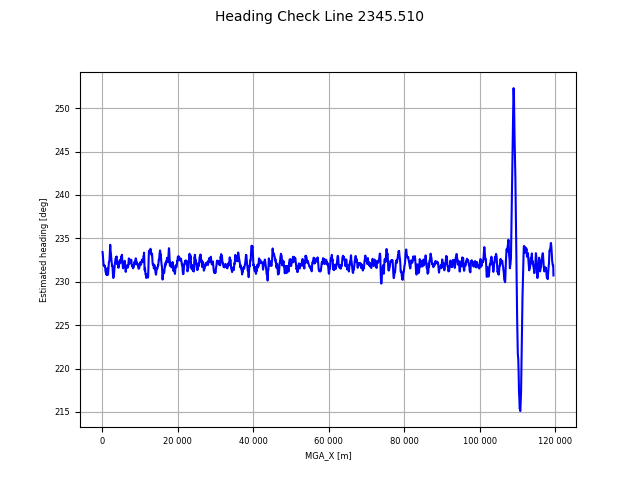

In [12]:
qc.checkHeading(EastVicHDF_file, [232.0, 52], plot_flag=True)

___

**Ground Speed**

The data are measured at constant sample rate in time but we are interested in the location of the data in space and the data will be at a constant spacing on the ground only if the aircraft ground speed is constant. Tail winds and head winds make this difficult and some variation is inevitable.

When the aircraft flies is slower into a head wind the data have better spatial resolution, but a tail wind causes a faster ground speed and consequently poorer spatial resolution. In most conditions, a survey aircraft can fly within $15\%$ - $20\%$ of nominal, although nominal can vary significantly with aircraft.

This example requires the data to be within $15\%$ of $60\,ms^{-2}$, with exceedances to persist for no further than $1000\,m$.

In [ ]:
qc.checkSpeeds(EastVicHDF_file, nominalSpeed=60., allowance=0.15, maxDistance=1000.0, plot_flag=False)